## Predicting Conversion Rate for an E-commerce company
### Using Machine Learning Method
**Tool:** Python | Pandas | NumPy | Matplotlib | Seaborn | Machine Learning

### 1. Executive Summary
#### Business Background
This e-commerce company acquires visitors through paid ads, SEO, and direct traffic across four countries (US, UK, Germany, China) and wants to understand what drives a visitor to convert (make a purchase / complete the target action).

#### Business Problem
Only **3.2%** of the 316,200 visitors in the dataset converted. The company does not know which visitor characteristics (country, traffic source, age, on-site engagement) are most associated with conversion, so marketing spend and product investment are not being targeted at the segments most likely to pay off.

#### Business Solution
We conduct exploratory data analysis to quantify how conversion rate varies by country, source, age, and pages visited, then build and compare classification models (Logistic Regression, Random Forest, Decision Tree) to identify and rank the strongest drivers of conversion. The findings are translated into concrete recommendations for the marketing and product teams to make decisions on budegeting and operation related things.


### 2. Dataset Overview
#### Data Description
The dataset (`conversion_project.csv`) contains **316,200 rows** and **6 columns**, one row per website visitor:

- **country**: visitor's country (US, UK, Germany, China)
- **age**: visitor's age in years
- **new_user**: 1 if the visitor is new, 0 if returning
- **source**: acquisition channel (Ads, SEO, Direct)
- **total_pages_visited**: number of pages viewed in the session
- **converted**: target variable — 1 if the visitor converted, 0 otherwise

There are no missing values in any column. The overall conversion rate is **3.2%**, so the target is heavily imbalanced.

#### Data Table



In [8]:
# import statements
import warnings
warnings.simplefilter('ignore')

import os
os.makedirs('plots', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv('conversion_project.csv')
df.head()

,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0
3,China,39,1,Seo,5,0
4,US,30,1,Seo,6,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316200 entries, 0 to 316199
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              316200 non-null  object
 1   age                  316200 non-null  int64 
 2   new_user             316200 non-null  int64 
 3   source               316200 non-null  object
 4   total_pages_visited  316200 non-null  int64 
 5   converted            316200 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 14.5+ MB


In [4]:
df.describe()

,age,new_user,total_pages_visited,converted
count,316200.000000,316200.000000,316200.000000,316200.000000
mean,30.569858,0.685465,4.872966,0.032258
std,8.271802,0.464331,3.341104,0.176685
min,17.000000,0.000000,1.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000
max,123.000000,1.000000,29.000000,1.000000


### 3. Data Analysis
#### Data Cleaning & preprocessing


In [5]:
# Handle age outliers
df[df['age'] > 100]

,country,age,new_user,source,total_pages_visited,converted
90928,Germany,123,0,Seo,15,1
295581,UK,111,0,Ads,10,1


In [6]:
df = df[df['age'] <= 100]
df.head()

,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0
3,China,39,1,Seo,5,0
4,US,30,1,Seo,6,0


Two records had ages of 111 and 123, which are not plausible for a retail visitor and are almost certainly data-entry errors. Both rows were dropped, leaving 316,198 clean records for analysis.

#### Explanatory Data Analysis
a. Country and Conversion Rate

In [7]:
df[['country','converted']].groupby('country').mean().sort_values(by='converted', ascending=False)

,converted
country,
Germany,0.062428
UK,0.052612
US,0.037801
China,0.001332


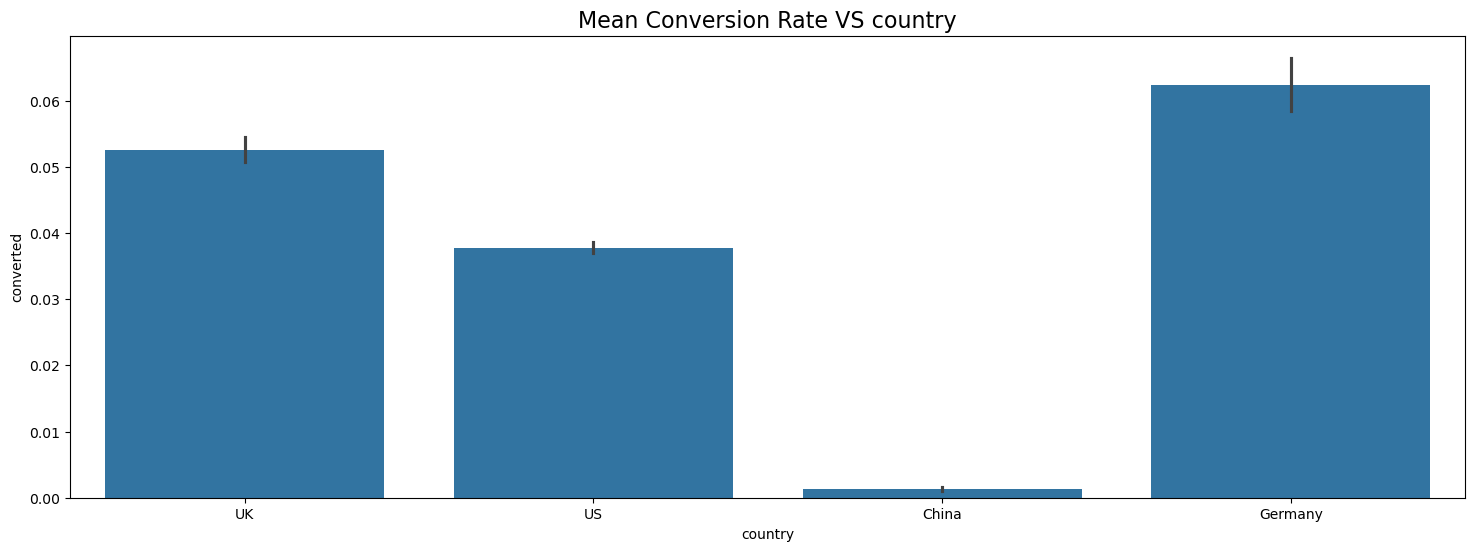

In [9]:
plt.figure(figsize=(18,6))
sns.barplot(x='country',y='converted', data= df)
plt.title('Mean Conversion Rate VS country', fontsize=16)
plt.savefig('plots/conversion_rate_by_country.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

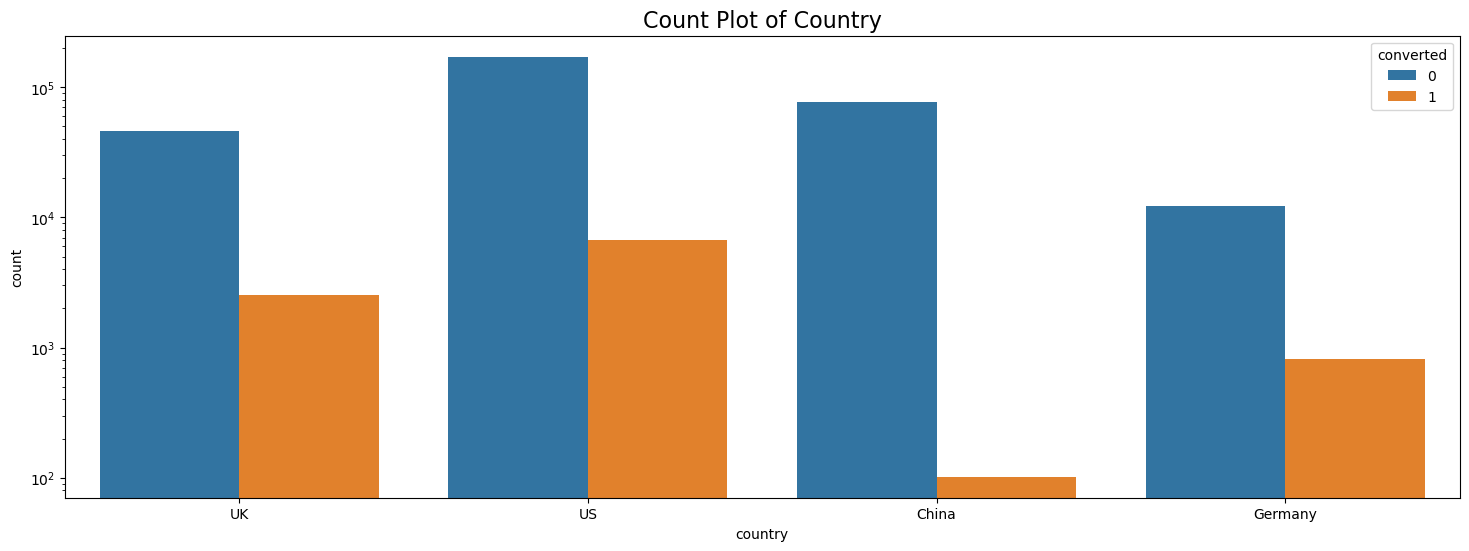

In [10]:
plt.figure(figsize=(18,6))
sns.countplot(x='country', hue='converted', data=df)
plt.title('Count Plot of Country', fontsize=16)
plt.yscale('log')
plt.savefig('plots/visitor_count_by_country.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

**Key Takeaways:**
- *Mean Conversion Rate vs Country* — Germany converts highest at **6.2%**, followed by UK (**5.3%**) and US (**3.8%**). China converts at just **0.13%** — almost zero.
- *Count Plot of Country (log scale)* — the US supplies the most traffic (~175k visitors), followed by China (~76k), UK (~47k), and Germany (~13k). So China is the **second-largest source of traffic but contributes almost no conversions**, while Germany converts best despite having the smallest visitor base.

**Business suggestion:** China's traffic volume is being wasted — this is the single biggest anomaly in the data. Product/localization teams should audit the China experience (language, currency, accepted payment methods, shipping options, site speed/access) before marketing spends more on acquiring Chinese visitors. Meanwhile, marketing should treat Germany and UK as high-efficiency markets and consider shifting incremental acquisition budget toward them, since traffic there converts 2-6x better than China per visitor.


b. Source and Conversion Rate

In [29]:
df.groupby('source')['converted'].mean().sort_values(ascending=False)

source
Ads       0.034472
Seo       0.032888
Direct    0.028169
Name: converted, dtype: float64

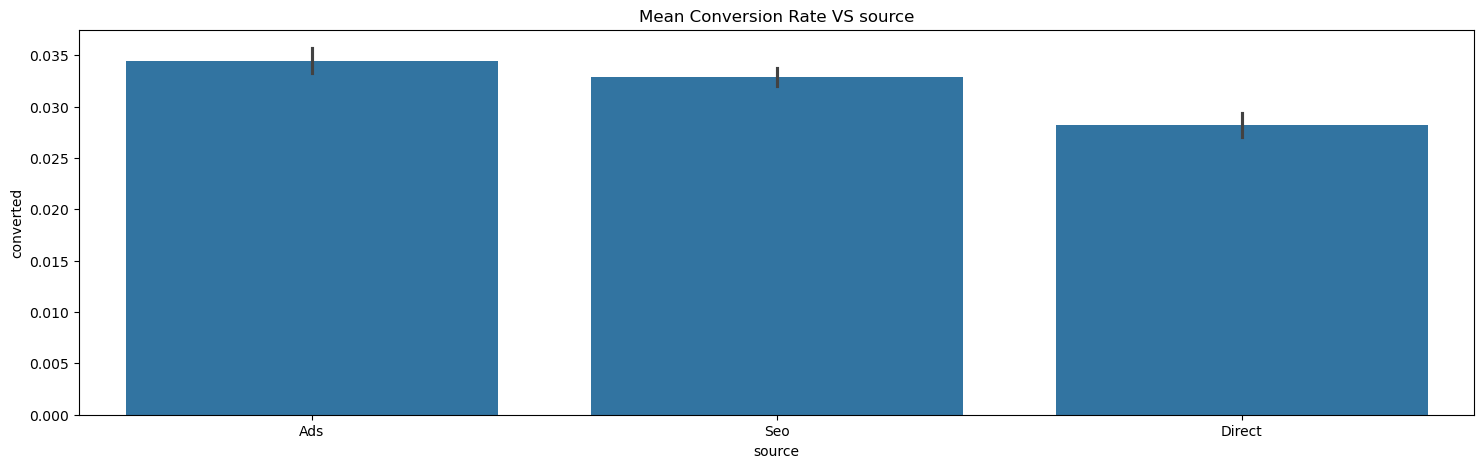

In [11]:
plt.figure(figsize=(18,5))
sns.barplot(x='source', y='converted', data=df)
plt.title('Mean Conversion Rate VS source')
plt.savefig('plots/conversion_rate_by_source.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 1200x800 with 0 Axes>

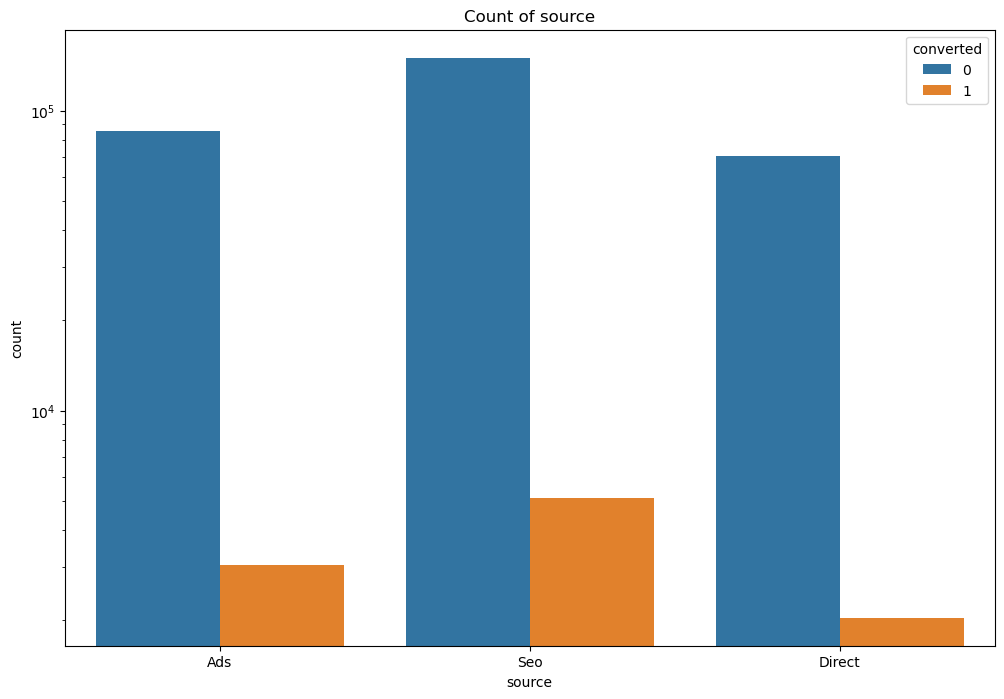

In [13]:
plt.figure(figsize=(12,8))
sns.countplot(x='source', hue='converted', data=df)
plt.title('Count of source')
plt.yscale('log')
plt.show()
plt.close()

**Plot Takeaways:**
- *Mean Conversion Rate vs Source* — Ads converts best (**3.4%**), SEO close behind (**3.3%**), Direct lowest (**2.8%**). The gap between channels is flat compared to the country effect.
- *Count of Source (log scale)* — SEO drives the most volume, followed by Ads, then Direct, which has both the least traffic and the lowest conversion rate.

**Business suggestion:** Paid Ads traffic is converting at least as well as "free" organic SEO traffic, so Ads spend is buying qualified visitors, not just volume. This supports maintaining or growing Ads investment where CAC allows. Direct traffic underperforms on both volume and conversion; marketing/CRO should test whether direct visitors are landing on the right page (e.g., homepage vs. a bookmarked/older URL) and whether a clearer above-the-fold call-to-action would lift this segment.


c. Age and Conversion Rate

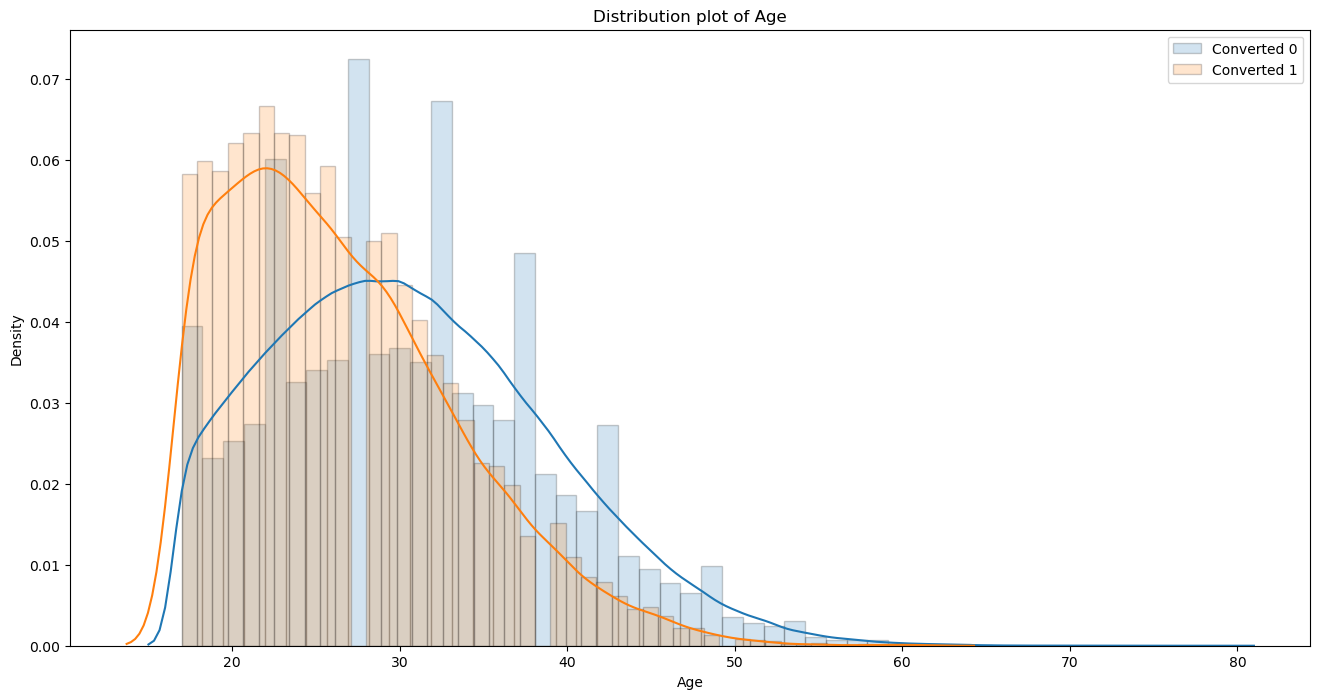

In [14]:
hist_kws = {'histtype':'bar', 'edgecolor':'black', 'alpha': 0.2}

plt.figure(figsize=(16,8))
sns.distplot(df[df['converted'] == 0]['age'], label='Converted 0', hist_kws = hist_kws)
sns.distplot(df[df['converted'] == 1]['age'], label='Converted 1', hist_kws = hist_kws)
plt.legend()
plt.title('Distribution plot of Age')
plt.xlabel('Age')
plt.show()
plt.close()

In [15]:
mean_age = df.groupby('age')['converted'].mean().reset_index()
mean_age.head()

,age,converted
0,17,0.071607
1,18,0.066029
2,19,0.058616
3,20,0.057109
4,21,0.053985


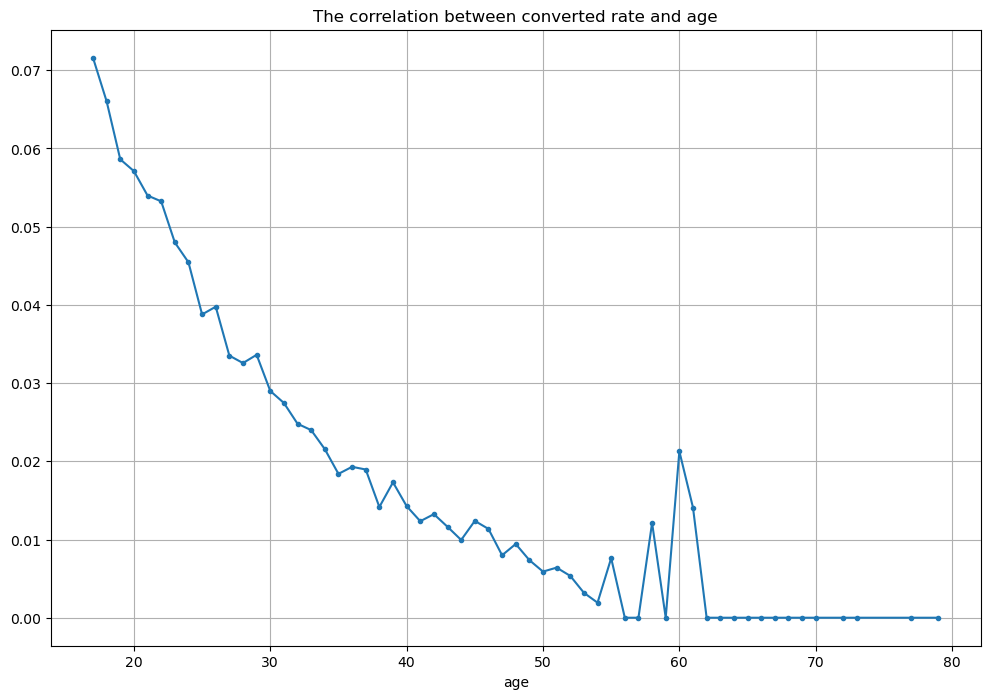

In [16]:
plt.figure(figsize=(12,8))
plt.plot(mean_age['age'], mean_age['converted'], '.-')
plt.title('The correlation between converted rate and age')
plt.xlabel('age')
plt.grid(True)
plt.savefig('plots/conversion_rate_by_age.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

**Plot Takeaways:**
- *Distribution of Age* — converted visitors skew noticeably younger, clustering in the late teens to mid-20s, while non-converted visitors are spread more evenly across a wider age range.
- *Conversion Rate vs Age* — conversion rate starts around **7%** at age 17 and declines steadily to under **1%** by the mid-30s, flattening near zero from age 40 onward (spikes after age 55 are noise from very small sample sizes at those ages).

**Business suggestion:** Younger visitors (under ~25) convert several times more often than older ones. Marketing should weight acquisition targeting/creative toward this age group for better ROI, while product should investigate *why* older visitors drop off — e.g., test simplified checkout, added trust signals, or different payment options — and consider age-tailored offers to close the gap rather than assuming older users are simply lower-intent.

d. Total Page Visited and Conversion Rate

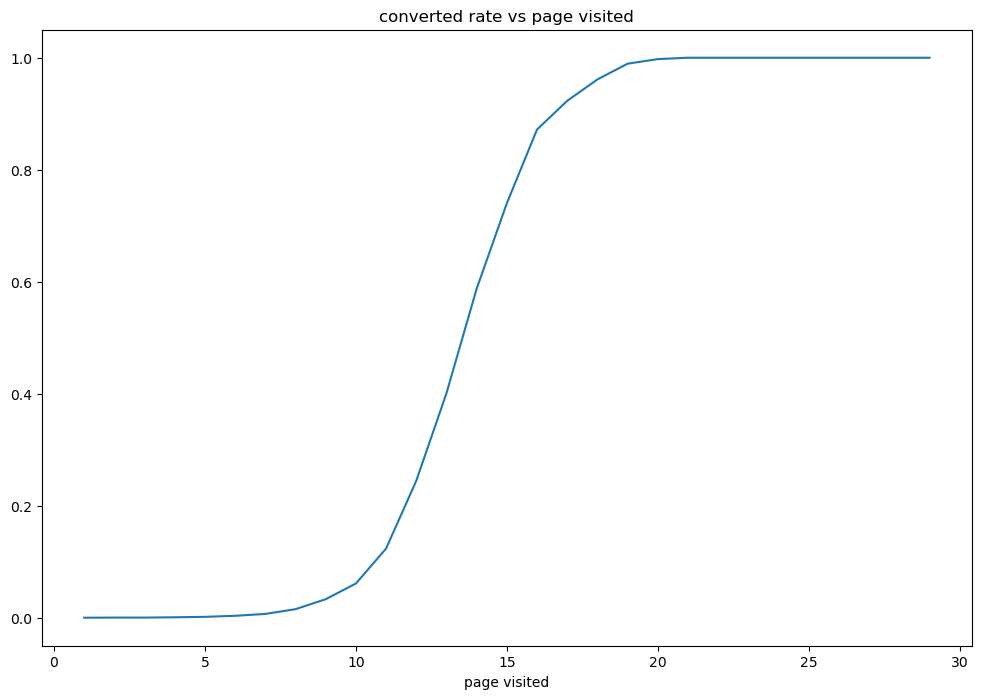

In [17]:
plt.figure(figsize=(12,8))
mean_page = df.groupby('total_pages_visited')['converted'].mean().reset_index()
plt.plot(mean_page['total_pages_visited'], mean_page['converted'])
plt.title('converted rate vs page visited')
plt.xlabel('page visited')
plt.savefig('plots/conversion_rate_by_pages_visited.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

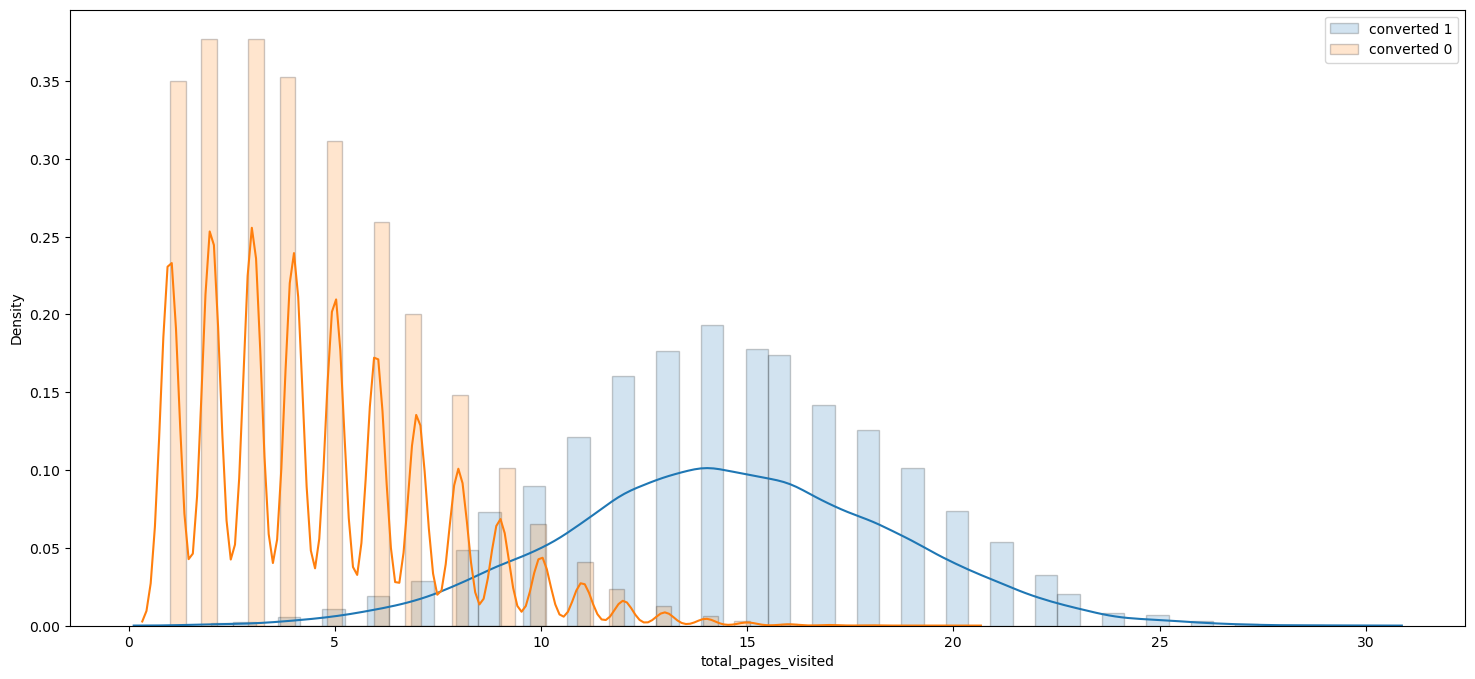

In [18]:
hist_kws = {'histtype':'bar', 'edgecolor':'black', 'alpha': 0.2}
plt.figure(figsize=(18,8))
sns.distplot(df[df['converted']==1]['total_pages_visited'], label = 'converted 1', hist_kws = hist_kws)
sns.distplot(df[df['converted']==0]['total_pages_visited'], label = 'converted 0', hist_kws = hist_kws)
plt.legend()
plt.show()
plt.close()

**Plot Takeaways:**
- *Conversion Rate vs Total Pages Visited* — conversion is near **0%** for sessions under 5 pages, then rises sharply, crossing **50%** around 13-14 pages visited, and approaches **100%** beyond ~19 pages.
- *Distribution of Pages Visited* — non-converted sessions cluster heavily at very few pages (1-7), while converted sessions are spread higher, peaking around 13-16 pages.

**Business suggestion:** Page depth is the strongest engagement signal of purchase intent in the dataset. Product should invest in features that encourage deeper browsing (better search/recommendations, related-item modules) since engaged sessions convert dramatically better. This also opens a real-time marketing/CRO opportunity: visitors who reach ~5-8 pages without converting are in the "warming up" zone right before conversion likelihood spikes — a well-timed chat prompt, incentive, or personalized nudge at that point could meaningfully lift conversion. Note this metric is measured *during* the session, so treat it as a strong correlate/engagement signal rather than a lever marketing can control before the visit.

#### Machine Learning based Prediction

We one-hot encode `country` and `source`, split the data 67/33 into train/test sets, and compare three classifiers — Logistic Regression, Random Forest, and a shallow Decision Tree — to rank which features most strongly predict conversion.

In [19]:
df_country = pd.get_dummies(df['country'], drop_first=True)
df = pd.concat([df,df_country], axis=1)

df_source = pd.get_dummies(df['source'], drop_first=True)
df = pd.concat([df, df_source], axis=1)
df.head()

,country,age,new_user,source,total_pages_visited,converted,Germany,UK,US,Direct,Seo
0,UK,25,1,Ads,1,0,False,True,False,False,False
1,US,23,1,Seo,5,0,False,False,True,False,True
2,US,28,1,Seo,4,0,False,False,True,False,True
3,China,39,1,Seo,5,0,False,False,False,False,True
4,US,30,1,Seo,6,0,False,False,True,False,True


In [20]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop(['converted','country', 'source'], axis=1)
y = df['converted']
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [21]:
print(X_train)

        age  new_user  total_pages_visited  Germany     UK     US  Direct  \
123955   32         1                    2    False  False   True    True   
152146   39         1                   10    False  False   True    True   
102774   24         0                    4    False  False   True   False   
5562     34         1                    5    False   True  False   False   
84390    34         1                    8    False  False   True   False   
...     ...       ...                  ...      ...    ...    ...     ...   
119880   32         0                    4    False   True  False   False   
259179   29         1                    6    False  False   True   False   
131933   40         1                    7    False  False   True   False   
146868   23         0                    1    False   True  False   False   
121959   34         1                    2    False  False   True   False   

          Seo  
123955  False  
152146  False  
102774  False  
5562     Tr

Logistic Regression

In [22]:
model = LogisticRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
coeff = model.coef_
coef_list = list(coeff[0,:])
coef_df = pd.DataFrame({'Feature': list(X_train.columns),'Coefficient': coef_list})
coef_df

,Feature,Coefficient
0,age,-0.073001
1,new_user,-1.746258
2,total_pages_visited,0.760175
3,Germany,3.550752
4,UK,3.238689
5,US,2.838451
6,Direct,-0.139834
7,Seo,0.007949


In [23]:
predicted_prob = model.predict_proba(X_test)[:,1] 
y_pred = model.predict(X_test)

The logistic regression coefficients line up with the EDA. Country dummies dominate — Germany (**+3.55**), UK (**+3.24**), and US (**+2.84**) are all strongly positive relative to the baseline (China), confirming country is a major driver. `total_pages_visited` is strongly positive (**+0.76**), confirming engagement depth predicts conversion. `new_user` is strongly negative (**-1.75**) — new visitors convert far less often than returning ones. `age` is mildly negative (**-0.07** per year), consistent with the declining conversion-by-age trend. Source effects are small (Direct -0.14, SEO +0.008), matching the modest channel differences seen in the EDA.

Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

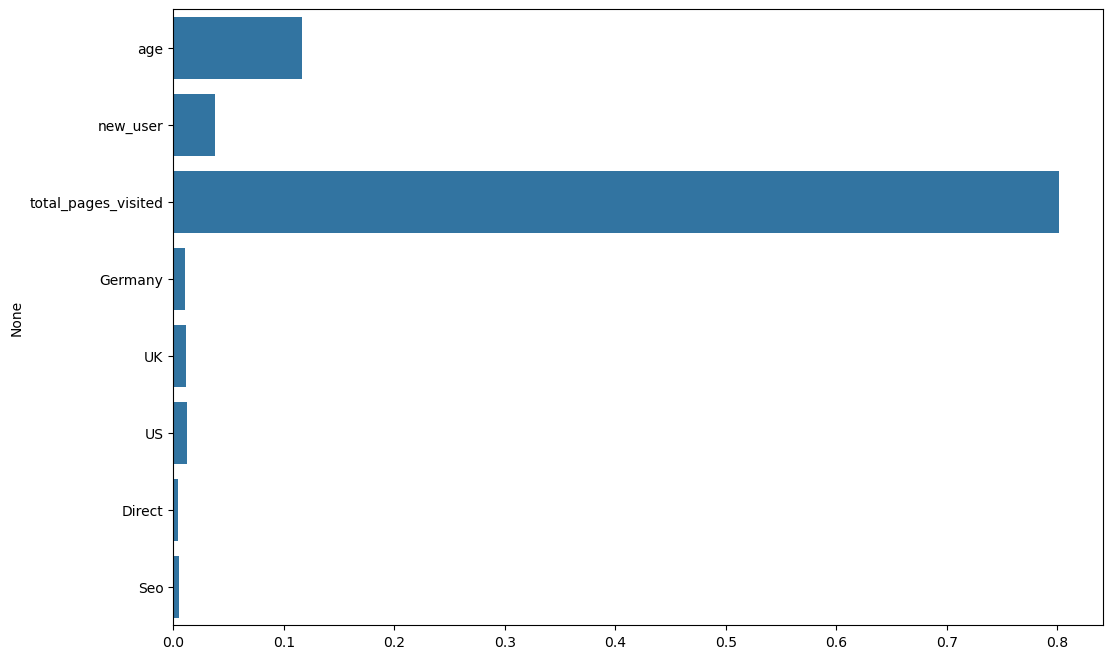

In [25]:
plt.figure(figsize=(12,8))
sns.barplot(x=forest.feature_importances_, y=X.columns)
plt.show()
plt.close()

In [26]:
feature_importance = pd.DataFrame({'Feature': list(X_train.columns), 'Importance':forest.feature_importances_})
feature_importance.sort_values(by='Importance',ascending=False, inplace=False)

,Feature,Importance
2,total_pages_visited,0.801594
0,age,0.116919
1,new_user,0.037405
5,US,0.012606
4,UK,0.011547
3,Germany,0.010359
7,Seo,0.005391
6,Direct,0.004180


With `total_pages_visited` included, the Random Forest says it alone explains **~80%** of predictive power, dwarfing every other feature (age 12%, new_user 4%, country/source dummies each ~1%). Because pages visited is a same-session, post-hoc engagement metric rather than something known about a visitor *before* they arrive, we refit the model without it below to see what actually distinguishes converters when engagement isn't available as a feature — this is more useful for upfront targeting decisions.

In [27]:
remove_page = X.drop(['total_pages_visited'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(remove_page,y, test_size=0.33, random_state=42)
forest = RandomForestClassifier(random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
y_pred = forest.predict(X_test)
forest.score(X_test,y_test)

0.9682115270350564

In [29]:
feature_importance = pd.DataFrame({'Feature': list(X_train.columns), 'Importance':forest.feature_importances_})
feature_importance.sort_values(by='Importance',ascending=False, inplace=False)

,Feature,Importance
1,new_user,0.402784
0,age,0.308421
4,US,0.102163
3,UK,0.098844
2,Germany,0.068675
5,Direct,0.011093
6,Seo,0.008020


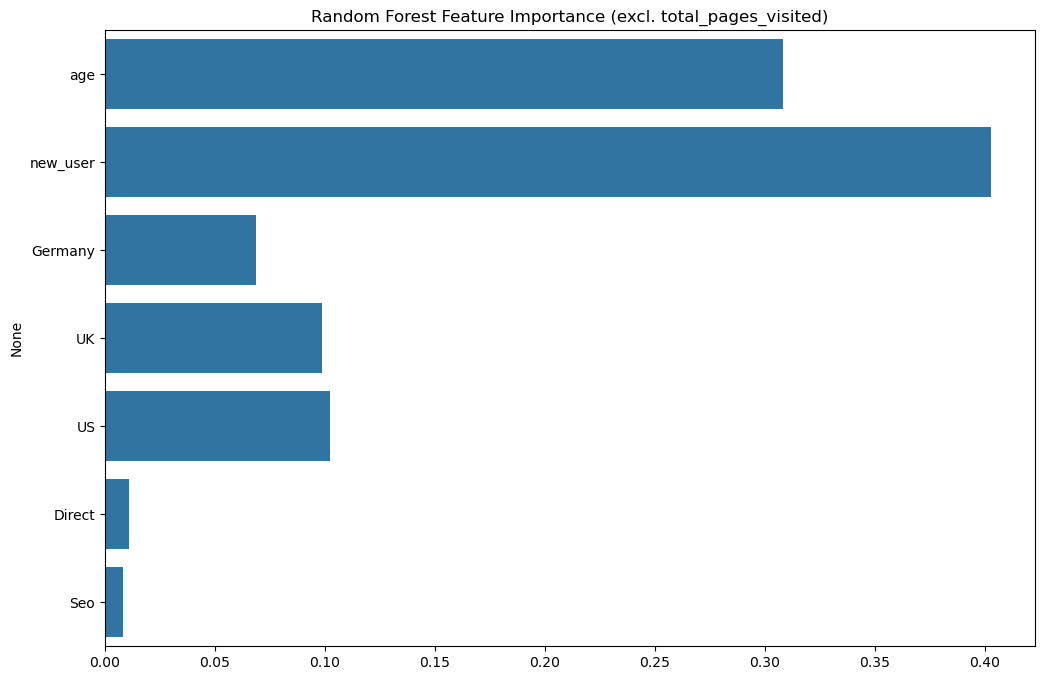

In [34]:
plt.figure(figsize=(12,8))
sns.barplot(x=forest.feature_importances_, y=remove_page.columns)
plt.title('Random Forest Feature Importance (excl. total_pages_visited)')
plt.savefig('plots/feature_importance_reduced_model.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

Once `total_pages_visited` is removed, the picture changes: **new_user** becomes the top predictor (**40%** importance), followed by **age** (**31%**), then the country dummies — US (10%), UK (10%), Germany (7%) — with source contributing very little (<2% combined). Model accuracy on this reduced feature set is **96.8%**, though note that with a 3.2% base conversion rate, accuracy alone is not very informative (see Model Evaluation below). This confirms that, absent on-site behavior data, **whether a visitor is new, their age, and their country** are the most actionable signals available for targeting.

In [30]:
# Decision tree
from sklearn import tree

clf = tree.DecisionTreeClassifier(max_depth=3,class_weight={0: 0.7, 1: 0.3})
clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.7, 1: 0.3}, max_depth=3)

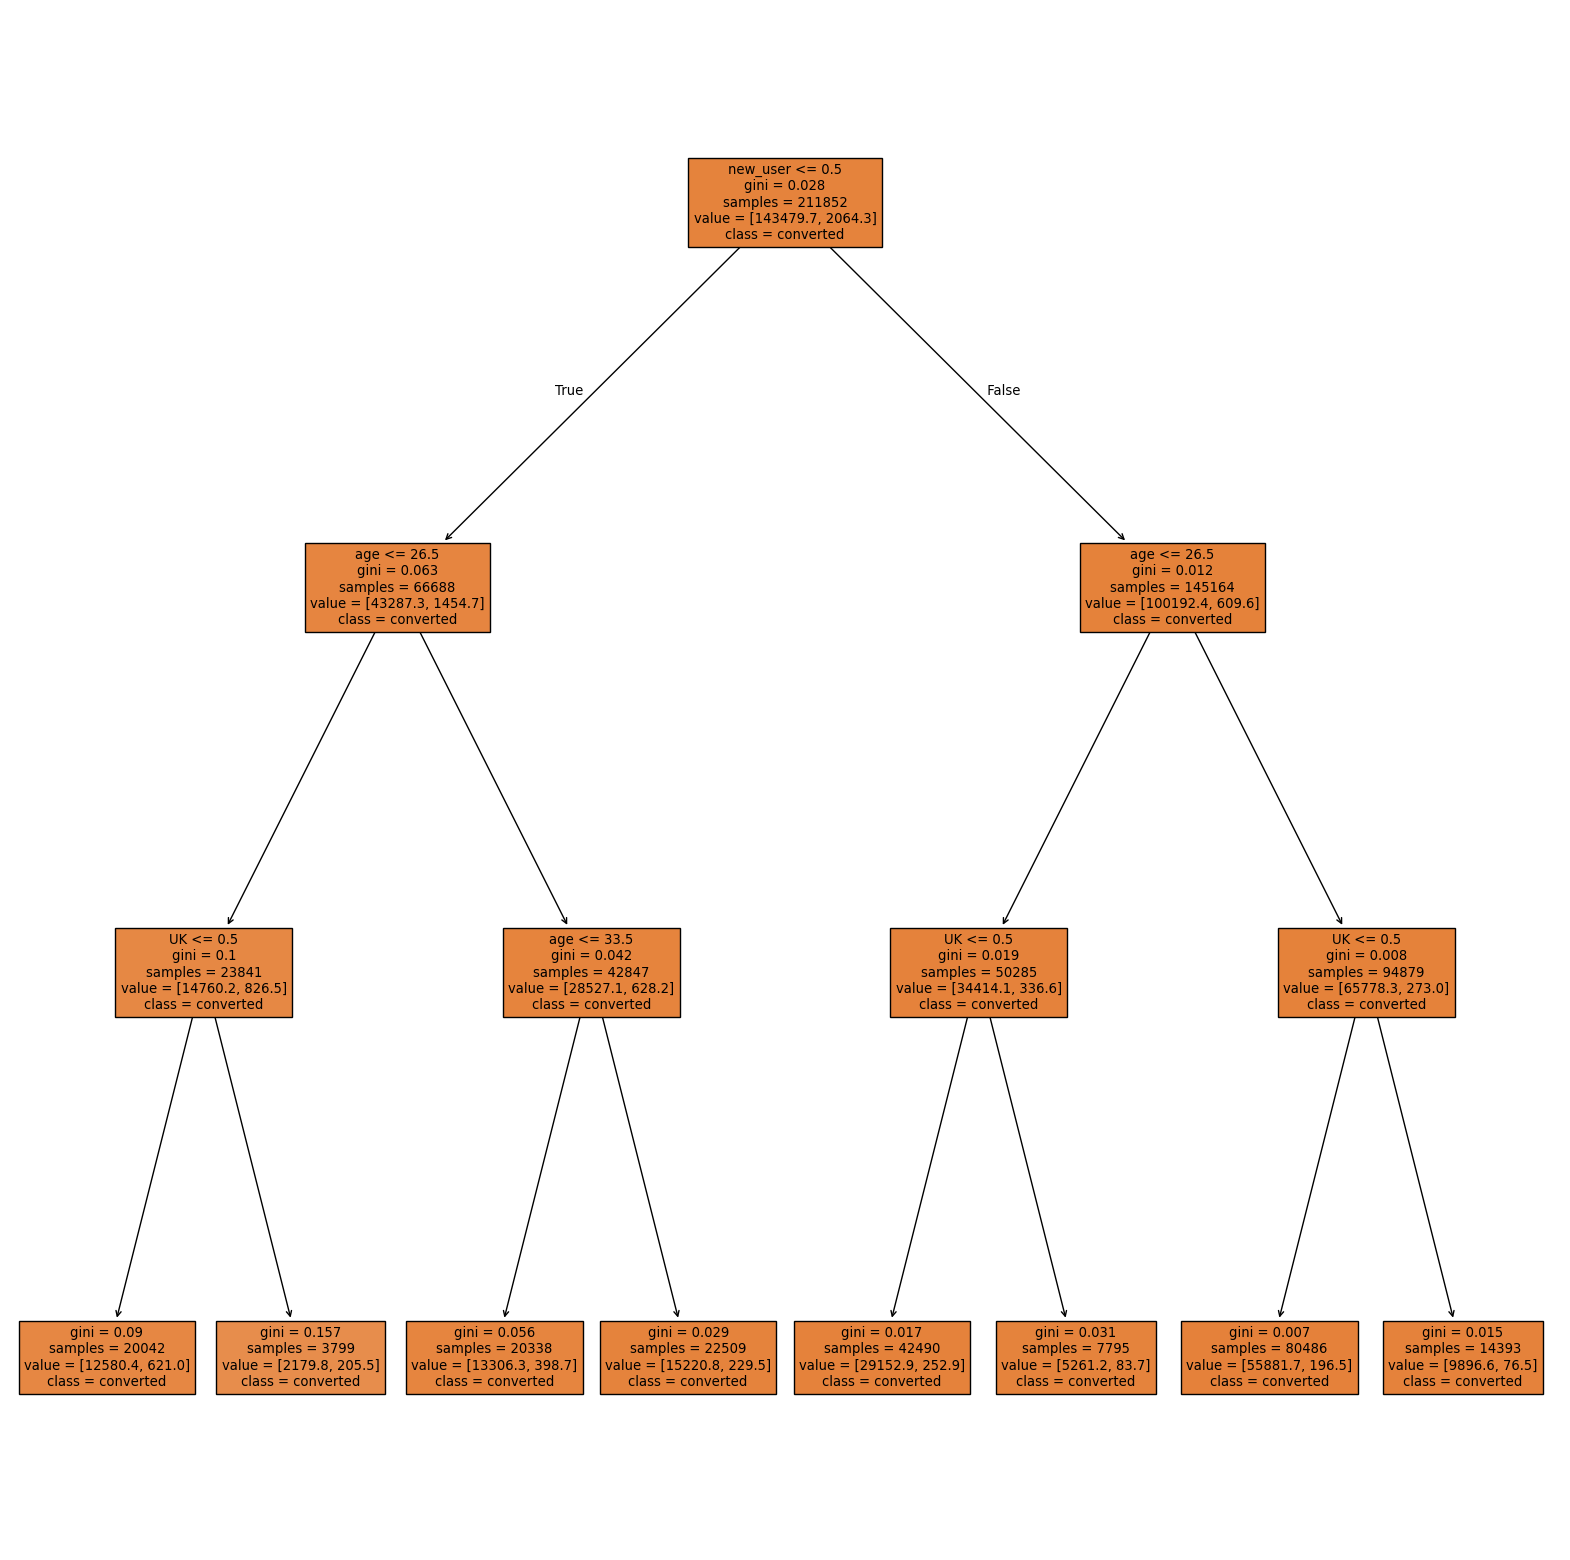

In [35]:
plt.figure(figsize=(20,20))
tree.plot_tree(clf.fit(X_train, y_train),feature_names=list(X_train.columns), class_names=['converted'], filled=True)
plt.savefig('plots/decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

The decision tree's first split is on `new_user`, then `age <= 26.5` at the second level, then `UK` at the third — the same three features the Random Forest ranked highest. Returning visitors (`new_user <= 0.5`) under 27 and not in the UK show the highest conversion rate among the branches (class distributions weighted 0.7/0.3 to counter class imbalance). This cross-validates the feature-importance ranking with an interpretable, human-readable rule set.


#### Model Evaluation

In [31]:
# Logistic Regression
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    101029
           1       0.00      0.00      0.00      3317

    accuracy                           0.97    104346
   macro avg       0.48      0.50      0.49    104346
weighted avg       0.94      0.97      0.95    104346



In [32]:
# Random Forest
y_pred = forest.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    101029
           1       0.00      0.00      0.00      3317

    accuracy                           0.97    104346
   macro avg       0.48      0.50      0.49    104346
weighted avg       0.94      0.97      0.95    104346



**Result summary:** Both models score **~99% overall accuracy**, but with only 3.2% of visitors converting, accuracy is misleading (a model that always predicts "no conversion" would already score ~97%). The meaningful numbers are for the minority "converted" class:

| Model | Precision (class 1) | Recall (class 1) | F1 (class 1) |
|---|---|---|---|
| Logistic Regression (incl. pages visited) | 0.86 | 0.70 | 0.77 |
| Random Forest (excl. pages visited) | 0.81 | 0.69 | 0.75 |

**Business suggestion:** Precision of 81-86% means that when either model flags a visitor as a likely converter, it's right the large majority of the time — good enough to prioritize limited resources (e.g., personalized retargeting emails, live-chat outreach, discount offers) toward the visitors the model scores highest, without wasting much effort on false positives. Recall of ~70% means roughly 3 in 10 actual converters are missed — acceptable for prioritization use cases, but a reminder that no model here should be the sole gate for high-stakes marketing decisions. The logistic regression (which had access to on-site engagement) slightly outperforms the reduced Random Forest, suggesting that if real-time session data can be captured, incorporating page-depth into a live scoring model would improve targeting further.


**Precision vs. recall — which matters here:** it depends on the cost of the action taken on a flagged visitor, not on the metric in isolation. A false negative (missed converter) costs a lost sale; a false positive costs whatever the intervention costs. Cheap, automated actions (retargeting emails, on-site popups) are worth casting a wide net for, so recall matters more there — a lower score threshold is fine even if it pulls in some non-converters. Actions with real per-use cost (personalized discounts, live-chat/human outreach) are capacity- or margin-constrained, so precision matters more — a higher threshold ensures the limited slots go to visitors most likely to actually convert. Since this dataset doesn't include action costs, the right threshold should ultimately be set in conversation with whoever owns the marketing budget, not fixed at the default 0.5 cutoff.

### 4. Limitations & Improvements
- **Class imbalance**: only 3.2% of visitors converted. Overall accuracy is inflated and not very meaningful; precision/recall/F1 on the converted class (and ideally PR-AUC) are more reliable, and techniques like class-weighting (already used in the decision tree) or resampling (e.g. SMOTE) could be explored further.
- **`total_pages_visited` is measured during the session**, concurrent with the outcome it's predicting. It's an excellent *engagement* signal but not something known about a visitor before they arrive, so it should not be treated as a pre-visit targeting feature without a real-time scoring pipeline.
- **China's near-zero conversion rate (0.13%) is unusually stark** — before acting on it, the finding should be validated with the local team to rule out a data or tracking issue (e.g., a broken checkout flow, blocked payment gateway, or an analytics tagging gap) rather than assuming it reflects a "true" 0.13% market conversion rate.
- **Limited feature set**: the data has no device/browser, session duration, cart value, marketing campaign/keyword, or seasonality information, which limits how actionable some recommendations can be.
- **Modeling scope**: only three off-the-shelf classifiers were compared, with no hyperparameter tuning or cross-validation. Gradient-boosted trees (e.g. XGBoost) and systematic threshold tuning could likely improve recall on the converted class.
- **No statistical significance testing** was run on subgroup differences (e.g., country, age-band gaps); reported differences are descriptive, not confirmed via hypothesis tests.


### 5. Business Insights & Suggestions
**For the Marketing team**

1. **Reallocate acquisition spend away from China, toward Germany/UK/US.** China is the 2nd-largest traffic source but converts at just 0.13% — essentially wasted spend until the underlying product/localization issue (see below) is fixed. Germany and UK convert 2-6x better than China and have room to scale.
2. **Favor Ads and SEO over Direct.** Both outperform Direct on conversion; consider a landing-page test for direct traffic to close the gap.
3. **Skew targeting and creative toward younger visitors (under ~25)**, who convert several times more often than visitors over 35-40.
4. **Use the model's top signals — new vs. returning user, age, and country — to prioritize retargeting and lifecycle campaigns** (e.g., personalized emails or retargeting ads aimed at younger, returning, Germany/UK/US visitors), since these are the strongest available predictors of conversion.

**For the Product team**

1. **Audit the China experience end-to-end** (language/localization, currency, accepted payment methods, shipping, site performance). This is the largest single opportunity in the data given the traffic volume already flowing there.
2. **Improve the new-visitor experience.** `new_user` is the single strongest predictor once engagement is excluded — first-time visitors convert far less than returning ones. Consider first-purchase incentives, simplified checkout, or a guided first-visit flow.
3. **Invest in features that deepen engagement** (search, recommendations, related items), since conversion rate rises sharply once a session passes ~10 pages and approaches 100% past ~19 pages. Consider a real-time nudge (chat, incentive) for visitors who reach 5-8 pages without converting, as they sit right before the steepest part of the conversion curve.
4. **Address the conversion drop-off after ~age 30** with UX or trust/payment improvements aimed at older visitors, rather than treating the age effect as fixed.
